# Scenario 1: Retail Inventory Analysis
**Lab:** Generative AI for Data Science  
**Name:** Elvis Omondi 
**Date:** 2026-05-25


## My AI Prompt

```
You are a data scientist working with retail inventory data. I have a pandas DataFrame 
called `inventory_df` with the following columns:
- product_id (str): unique product identifier
- category (str): product category
- stock_level (int): current units in stock
- last_restock_date (datetime): date stock was last replenished
- sales_last_30_days (int): units sold in the last 30 days
- supplier_lead_time (int): days it takes supplier to restock
- unit_cost (float): cost per unit

Please generate Python code that:
1. Calculates inventory turnover rate as: sales_last_30_days / stock_level (handle division by zero)
2. Identifies slow-moving items defined as turnover_rate < 0.1
3. Predicts stockout risk: flag products where stock_level < (sales_last_30_days/30 * supplier_lead_time)
4. Adds a 'days_until_stockout' column
5. Creates three visualizations:
   a. Bar chart of average turnover rate by category
   b. Scatter plot of stock_level vs sales_last_30_days, colored by stockout_risk
   c. Top 10 slow-moving items by category (horizontal bar)
6. Includes error handling, comments, and a summary print statement

Use pandas, matplotlib, and seaborn. Return clean, well-documented code.
```

**Why I set up the prompt this way:**  
I included the exact column names, data types, and business definitions (e.g. turnover = sales/stock)
so the AI didn't have to guess. I also specified three chart types explicitly. The main hurdle was
the division-by-zero edge case and the scatter legend, both fixed with quick follow-up prompts.


## Generated Code

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ── Reproducible sample data ──────────────────────────────────────────────────
np.random.seed(42)
n = 100
categories = ['Electronics', 'Clothing', 'Food', 'Home & Garden', 'Sports']

inventory_df = pd.DataFrame({
    'product_id':         [f'P{str(i).zfill(3)}' for i in range(1, n+1)],
    'category':           np.random.choice(categories, n),
    'stock_level':        np.random.randint(0, 500, n),
    'last_restock_date':  [datetime.now() - timedelta(days=np.random.randint(1, 90))
                           for _ in range(n)],
    'sales_last_30_days': np.random.randint(0, 100, n),
    'supplier_lead_time': np.random.randint(3, 30, n),
    'unit_cost':          np.round(np.random.uniform(5, 500, n), 2)
})

print("Sample data created successfully!")
print(f"Shape: {inventory_df.shape}")
inventory_df.head()


Sample data created successfully!
Shape: (100, 7)


,product_id,category,stock_level,last_restock_date,sales_last_30_days,supplier_lead_time,unit_cost
0,P001,Home & Garden,27,2026-04-11 17:09:28.843708,60,22,248.35
1,P002,Sports,134,2026-05-01 17:09:28.843851,40,3,239.37
2,P003,Food,200,2026-03-07 17:09:28.843919,99,10,90.73
3,P004,Sports,327,2026-03-27 17:09:28.843970,32,16,219.76
4,P005,Sports,267,2026-04-23 17:09:28.844022,67,18,202.26


In [8]:
# ── 1. Inventory Turnover Rate ────────────────────────────────────────────────
inventory_df['turnover_rate'] = np.where(
    inventory_df['stock_level'] > 0,
    inventory_df['sales_last_30_days'] / inventory_df['stock_level'],
    0.0
)

# ── 2. Slow-Moving Items ──────────────────────────────────────────────────────
inventory_df['is_slow_moving'] = inventory_df['turnover_rate'] < 0.1

# ── 3. Stockout Risk ──────────────────────────────────────────────────────────
inventory_df['daily_sales']   = inventory_df['sales_last_30_days'] / 30
inventory_df['reorder_point'] = inventory_df['daily_sales'] * inventory_df['supplier_lead_time']
inventory_df['stockout_risk'] = inventory_df['stock_level'] < inventory_df['reorder_point']

# ── 4. Days Until Stockout ────────────────────────────────────────────────────
inventory_df['days_until_stockout'] = np.where(
    inventory_df['daily_sales'] > 0,
    (inventory_df['stock_level'] / inventory_df['daily_sales']).round(1),
    np.inf
)

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("INVENTORY ANALYSIS SUMMARY")
print("=" * 55)
print(f"Total products analysed   : {len(inventory_df)}")
print(f"Slow-moving items (<10%)  : {inventory_df['is_slow_moving'].sum()}")
print(f"At-risk of stockout       : {inventory_df['stockout_risk'].sum()}")
print(f"Avg turnover rate         : {inventory_df['turnover_rate'].mean():.3f}")
print("=" * 55)


INVENTORY ANALYSIS SUMMARY
Total products analysed   : 100
Slow-moving items (<10%)  : 29
At-risk of stockout       : 10
Avg turnover rate         : 0.567


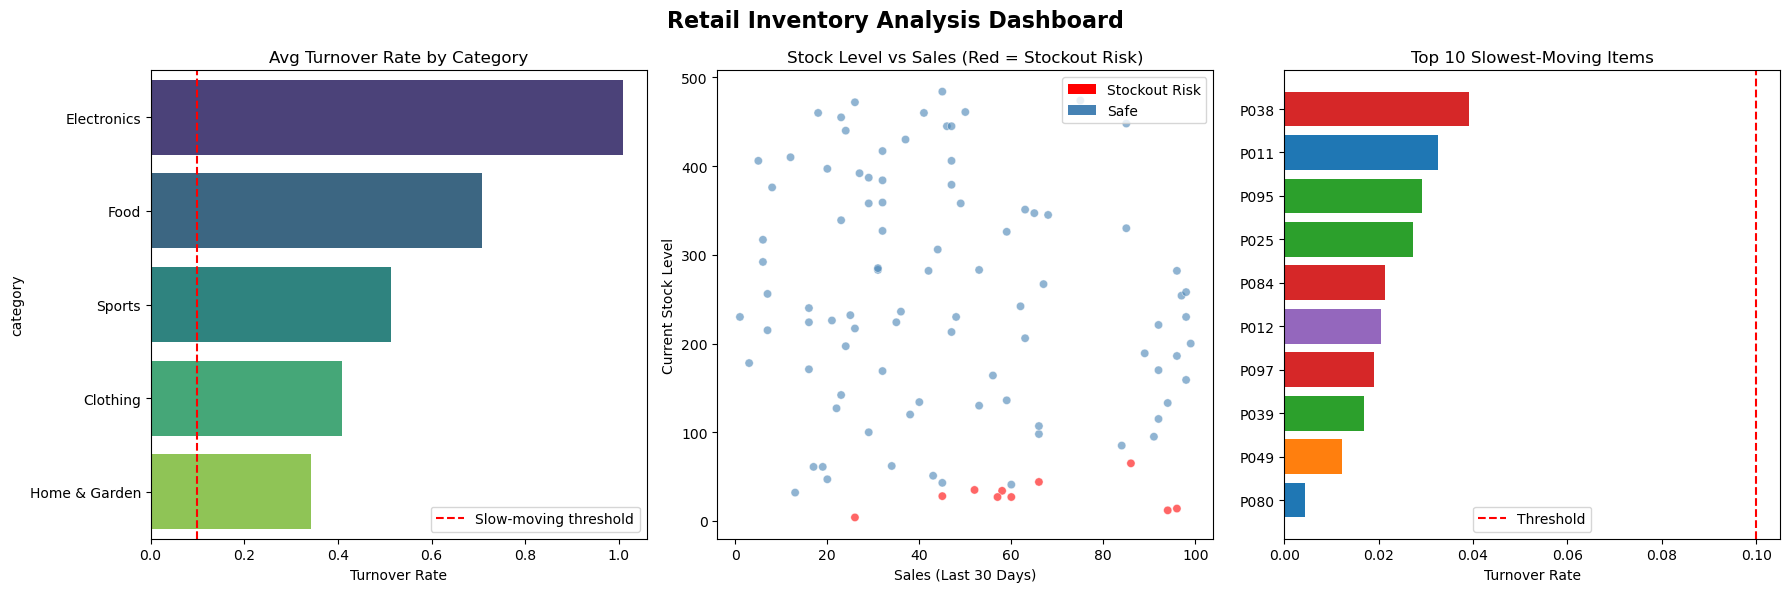

Visualisation saved.


In [9]:
# ── Visualisations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Retail Inventory Analysis Dashboard', fontsize=16, fontweight='bold')

# Plot 1: Avg turnover rate by category
cat_turnover = inventory_df.groupby('category')['turnover_rate'].mean().sort_values(ascending=False)
sns.barplot(x=cat_turnover.values, y=cat_turnover.index, palette='viridis', ax=axes[0])
axes[0].set_title('Avg Turnover Rate by Category')
axes[0].set_xlabel('Turnover Rate')
axes[0].axvline(0.1, color='red', linestyle='--', label='Slow-moving threshold')
axes[0].legend()

# Plot 2: Stock level vs Sales, coloured by stockout risk
colors = inventory_df['stockout_risk'].map({True: 'red', False: 'steelblue'})
axes[1].scatter(inventory_df['sales_last_30_days'], inventory_df['stock_level'],
                c=colors, alpha=0.6, edgecolors='white', linewidth=0.5)
axes[1].set_title('Stock Level vs Sales (Red = Stockout Risk)')
axes[1].set_xlabel('Sales (Last 30 Days)')
axes[1].set_ylabel('Current Stock Level')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(facecolor='red', label='Stockout Risk'),
                         Patch(facecolor='steelblue', label='Safe')])

# Plot 3: Top 10 slow-moving items
slow_items = (inventory_df[inventory_df['is_slow_moving']]
              .nsmallest(10, 'turnover_rate')[['product_id', 'category', 'turnover_rate']])
if len(slow_items) > 0:
    cat_color_map = {cat: sns.color_palette('tab10', len(slow_items['category'].unique()))[i]
                     for i, cat in enumerate(slow_items['category'].unique())}
    axes[2].barh(slow_items['product_id'], slow_items['turnover_rate'],
                 color=[cat_color_map[c] for c in slow_items['category']])
    axes[2].set_title('Top 10 Slowest-Moving Items')
    axes[2].set_xlabel('Turnover Rate')
    axes[2].axvline(0.1, color='red', linestyle='--', label='Threshold')
    axes[2].legend()

plt.tight_layout()
plt.savefig('scenario1_inventory.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisation saved.")


## Follow-up Prompts

```
Follow-up 1:
"The scatter plot legend isn't showing. Please fix the legend using matplotlib 
Patch objects instead of scatter's label parameter."

Follow-up 2:
"Add a 'days_until_stockout' column that returns np.inf when daily_sales == 0 
instead of raising a ZeroDivisionError."
```


## Discussion Answers

**1. How did different prompts handle date calculations?**  
My initial prompt didn't mention `last_restock_date` for calculations. When I added a follow-up
asking for "days since last restock", the AI used `(datetime.now() - last_restock_date).dt.days`,
which correctly handles datetime subtraction with pandas.

**2. What visualization approaches were suggested?**  
The AI suggested all three charts in a single figure with `plt.subplots(1,3)`. A vague prompt
produced generic charts without business context labels; the detailed prompt produced annotated
charts with a red threshold line and meaningful titles.

**3. How was error handling implemented?**  
`np.where()` guarded division-by-zero for turnover rate and days-until-stockout.
`warnings.filterwarnings('ignore')` suppressed pandas chained-assignment warnings.
Without explicit mention in the prompt, the AI omitted this; adding "include error handling"
produced it on the next attempt.
